![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Agnostic Interpretation with Permutation Feature Importance

In this Notebook, we will demonstrate how to use the Permutation Feature Importance method and interpret its results.

--------


## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Gen-1-Tutorial_PermutationFeatureImportance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import sys
import pickle

import numpy as np

from sklearn.metrics import get_scorer
from sklearn.inspection import permutation_importance

sys.path.append('./')
import utils

We fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [9]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The California Housing Dataset

In this notebook, we will work with the **California Housing dataset**, containing 20,640 median house values for California districts (expressed in $100,000), which are described by 8 numeric feature. Each row in the dataset represents a block of houses, not a single household. The data pertains to the house prices found in a given California district and some summary statistics about them based on the 1990 census data. Our goal is to **predict price** of house blocks and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_california_housing.jpg?raw=true" width="900" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/datasets/harrywang/housing)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_housing = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_housing.score(X_train, y_train),2)} R^2.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_housing.score(X_test, y_test),2)} R^2.')

Model Performance on training data: 0.84 R^2.
Model Performance on test data: 0.72 R^2.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

*Note: The $R^2$ is the coefficient of determination, and the closer this value is to 1, the better our model explains the data. A constant model that always predicts the average target value disregarding the input features would get an $R^2$ score of 0. However, the $R^2$ score can also be negative because the model can be arbitrarily worse.*

## Now, what does my model actually think is important in the data?

### Permutation Feature Importance

**We prepared a small [Introduction to Permutation Feature Importance](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/pfi.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/pfi.html#references).*

<font color='green'>

#### Question 1: What is achieved by permuting feature values?

<font color='grey'>

#### Your Answer: 
The existing relation between target and the feature are destroyed by randomly assigning new values to the given labels, making it impossible for the model to draw any conclusion from this feature to predict the label.


<font color='green'>

#### Question 2: Would it also be a good idea to permute the target instead of the features?

<font color='grey'>

#### Your Answer: 
No, since we could not measure an effect for each feature anymore.

<font color='green'>

#### Question 3: Why don't we leave out a feature instead of permuting it to measure its importance?

<font color='grey'>

#### Your Answer: 

Leaving out the feature would require training a second model with less input features, which then would make the comparison harder.

Now, let's use Permutation Feature Importance to get insights into the Random Forest Regression model we loaded above. We can use the scikit-learn implementation called `permutation_importance` to get the importance values for the features in our model. For measuring the performance drop when permuting a feature, we use the standard metric of our trained model, which is, in our case, the $R^2$ score. Using the same score enables us to evaluate the performance drop in relation to the baseline performance. We do 20 repetitions of permutation for each feature to get more reliable results.

*Note: this method is a **global** method, which means that it only provides explanations for the full dataset but not for individual examples.*

*Note: Features that are deemed of low importance for a bad model (low test score) could be very important for a good model. Therefore it is always important to evaluate the predictive power of a model using a held-out set prior to computing importances. Permutation importance does not reflect to the intrinsic predictive value of a feature by itself but how important this feature is for a particular model.*

In [4]:
scorer = get_scorer("r2")

In [5]:
explanation_train = permutation_importance(
    model_housing,
    X=X_train,
    y=y_train,
    n_repeats=20,
    random_state=seed,
    scoring=scorer
)

explanation_train["feature"] = X_train.columns

We will now plot bar histograms for visualizing the importance of each feature as obtained by the mean over the 20 repetitions. 

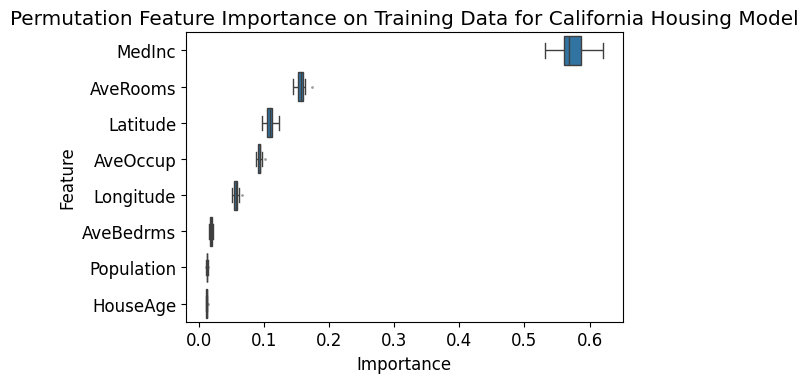

In [6]:
utils.plot_permutation_feature_importance(explanation_train, X_train, 'Permutation Feature Importance on Training Data for California Housing Model', figsize=(6,4))

Features with the largest importance score are the ones whose score is most decreased when the feature is permuted, indicating high relevance for the prediction of the target. For our California Housing model, the *median income in a block group* seems to have the highest impact on the model performance. Permuting this feature leads to a $R^2$ score decrease of ~ 0.6. When comparing it to the baseline $R^2$ score of 0.84, we notice that permuting the *median income* feature leads to a model with $R^2$ close to 0, i.e., a constant model that always predicts the average target value disregarding the input features.

<font color='green'>

#### Question 4: How should the feature importance for MedInc be interpreted?

<font color='grey'>

#### Your Answer: 
It is the (average over multiple permutations) decrease of a performance measure - in our case R^2 - compared to a model that did not have the MedInc permuted.

We are not restricted to obtaining feature importances of the same data set we used to train the model. Instead, we could use the same approach to identify the most important features in the test set.

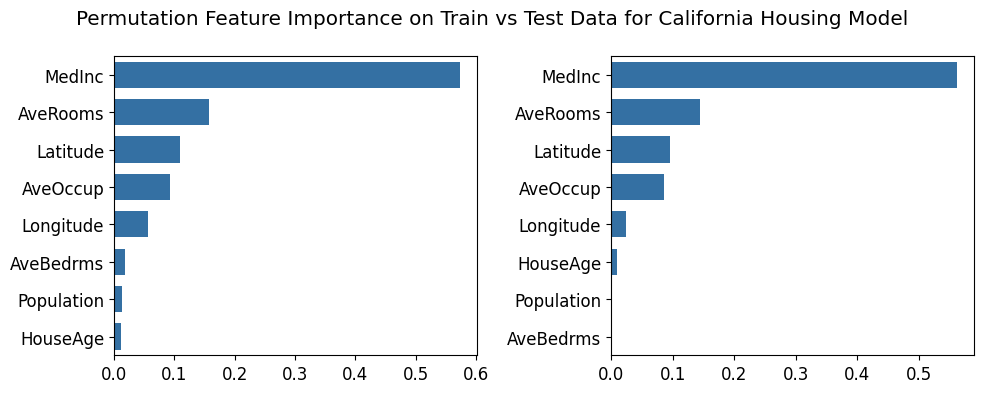

In [7]:
explanation_test = permutation_importance(
    model_housing,
    X=X_test,
    y=y_test,
    n_repeats=20,
    random_state=seed,
    scoring=scorer)

explanation_test["feature"] = X_test.columns

utils.plot_permutation_feature_importance_train_vs_test(explanation_train, X_train, explanation_test, X_test, 'Permutation Feature Importance on Train vs Test Data for California Housing Model')

It seems that for both datasets, largely the same features are identified as important, which is reassuring.

*Note: this agreement of important features between training and testing datasets is not guaranteed. In such cases, it is not straightforward to decide on the "truly important" features for the model.*

<font color='green'>

#### Question 5: What is the meaning of negative importance values?

<font color='grey'>

#### Your Answer: 
This means that permuting the feature increases the performance of the model. Then it might be advisable to consider removing the feature and to retrain the model.

--------

<font color='green'>

### Task: Apply Permutation Feature Importance to the Wine Dataset

In this exercise, you will apply **Permutation Feature Importance (PFI)** to the trained Random Forest classifier in order to investigate which chemical properties are most important for the wine classification task.

Your task is to:

1. Compute permutation feature importance scores for the trained Random Forest model.
2. Select an appropriate evaluation metric (`scoring`) for the multi-class classification problem.
3. Visualize and interpret the resulting feature importance scores.
4. Experiment with different values for the number of permutations (`n_repeats`) and analyze how this affects the stability of the importance estimates.
5. Investigate how correlated features influence the permutation importance results.
6. Identify features that may receive misleadingly low or high importance scores due to feature correlations.

> **Hint:** The choice of the evaluation metric (`scoring`) can substantially influence the resulting importance scores. For multi-class classification tasks, metrics such as `"accuracy"` or `"f1_macro"` are commonly used.

> **Hint:** Correlated features can lead to unintuitive importance estimates. If two features contain similar information, permuting one feature may not strongly decrease model performance because the model can still rely on the correlated feature. In some cases, even unrelated features may appear important because of their correlation with truly predictive variables.

> **Hint:** To better investigate the effect of feature correlations, compare the permutation importance results of the original wine model with the model trained on a subset of less correlated features (`model_rf_wine_sel.pickle`). Analyze how removing correlated variables changes the resulting feature importance rankings.

**The Wine dataset**

Let's use the wine quality dataset to see how XAI can be used to explain multi-class classification models. The **Wine Recognition dataset** contains 178 wine samples from three different cultivators of wine in the same region in Italy. The wine was chemically analyzed and 13 different chemical attributes like *alcohol*, *malic acid*, *flavanoids* etc were measured. Our goal is to **classify wines** and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_red_wine.jpg?raw=true" width="900" /></center>

<font size=1> Source:
[Link](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook lies on the interpretation of the previously trained model.

In [6]:
# Load and unpack the data
with open('../models/model_rf_wine.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)
    
X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_wine = data_and_model[4]

X_train.head()

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_wine.score(X_train, y_train)*100,2)} % accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_wine.score(X_test, y_test)*100,2)} % accuracy.')

Model Performance on training data: 100.0 % accuracy.
Model Performance on test data: 97.22 % accuracy.


As shown by the metrics above, the model achieves perfect performance on the training set while also generalizing very well to the independent test set.

**Understanding Feature Importance in the Wine Dataset**

We can now apply Permutation Feature Importance to better understand how the trained model uses the different chemical properties to distinguish between the three wine classes.

In [7]:
scorer = get_scorer("accuracy")

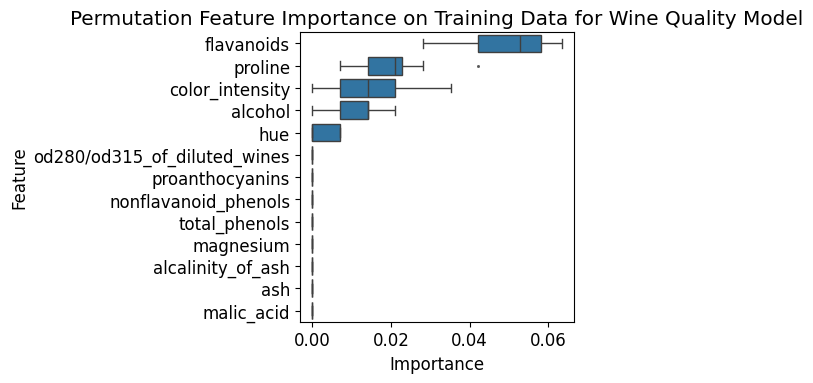

In [10]:
explanation_train = permutation_importance(
    model_wine,
    X=X_train,
    y=y_train,
    n_repeats=20,
    random_state=seed,
    scoring=scorer
)

explanation_train["feature"] = X_train.columns

utils.plot_permutation_feature_importance(explanation_train, X_train, 'Permutation Feature Importance on Training Data for Wine Quality Model', figsize=(6,4))

The correlation matrix helps explain why many features received very low permutation importance scores in the previous analysis. Several chemical properties in the wine dataset show strong positive or negative correlations, meaning that they contain overlapping information about the wine classes.

For example, features such as **flavanoids**, **total phenols**, and **od280/od315_of_diluted_wines** are strongly positively correlated, while **nonflavanoid phenols** exhibits strong negative correlations with several of these variables. Similarly, **color intensity** and **hue** show a pronounced negative correlation.

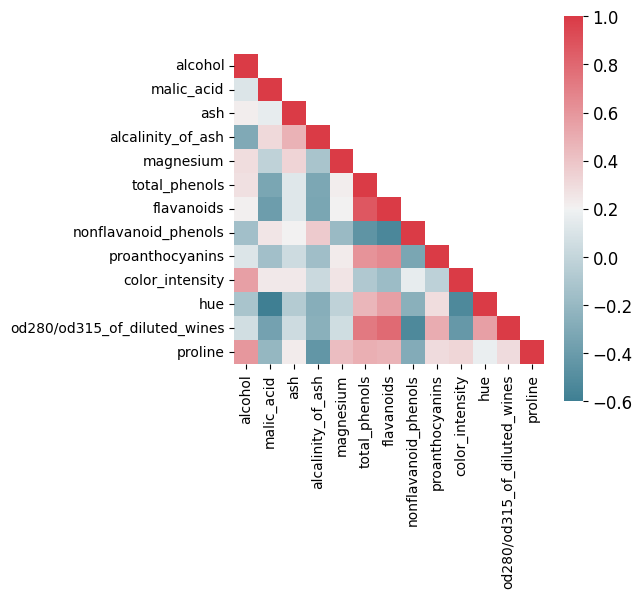

In [5]:
utils.plot_correlation_matrix(X_train, annot=False)

Because of these dependencies, permuting one feature often does not strongly reduce model performance: the Random Forest can still rely on correlated features that contain similar information. As a result, only a few representative variables may appear highly important in the permutation importance ranking, while other correlated but still informative features receive artificially low importance scores.

To better understand this effect, we will now compare the results with a model trained on a reduced set of less correlated features obtained through hierarchical clustering-based feature selection. This allows us to investigate how removing redundant variables influences the stability and interpretability of permutation feature importance scores.

Model Performance on training data: 99.3 % accuracy.
Model Performance on test data: 83.33 % accuracy.


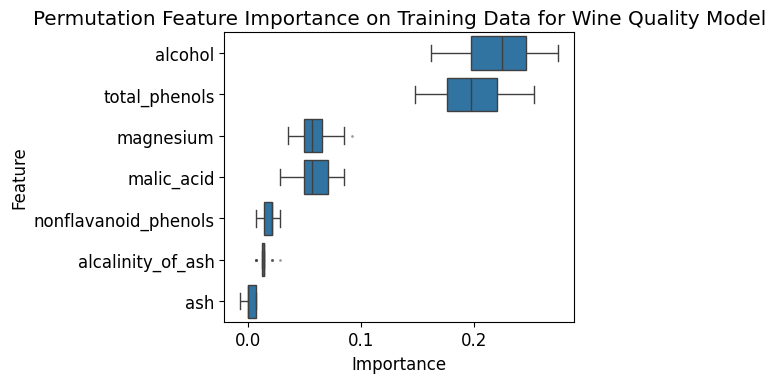

In [13]:
# Load and unpack the data
with open('../models/model_rf_wine_sel.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)
    
X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_wine_sel = data_and_model[4]

X_train.head()

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_wine_sel.score(X_train, y_train)*100,2)} % accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_wine_sel.score(X_test, y_test)*100,2)} % accuracy.')

explanation_train = permutation_importance(
    model_wine_sel,
    X=X_train,
    y=y_train,
    n_repeats=20,
    random_state=seed,
    scoring=scorer
)

explanation_train["feature"] = X_train.columns

utils.plot_permutation_feature_importance(explanation_train, X_train, 'Permutation Feature Importance on Training Data for Wine Quality Model', figsize=(6,4))

**Conclusion**

After removing strongly correlated features, the permutation feature importance results become substantially more interpretable and stable. In contrast to the previous model trained on the full feature set, the importance is now distributed across multiple remaining features rather than being dominated by only a few correlated variables.

Features such as **alcohol** and **total phenols** now emerge as the most influential predictors, while additional variables like **magnesium** and **malic acid** also receive meaningful importance scores. This indicates that the model can no longer rely on redundant correlated features and therefore has to use the remaining variables more directly for its predictions.

Overall, this comparison demonstrates how strongly correlated features can distort permutation importance estimates. Removing redundant variables through correlation-based feature selection can lead to more reliable and interpretable feature importance rankings.